In [1]:
import torch
import numpy as np
import pandas as pd
import importlib
import sys
from pathlib import Path
from sklearn.metrics import classification_report
from torch.utils.data import Dataset, DataLoader

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "task6").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import task6.utils.balance_dataset as balance_dataset
importlib.reload(balance_dataset)

augment_minority_classes = balance_dataset.augment_minority_classes
augment_minority_class_back_translation = balance_dataset.augment_minority_class_back_translation
from task6.utils.prepare_data import prepare_data

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Uni\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Uni\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [43]:
import torchvision

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


AttributeError: partially initialized module 'torchvision' has no attribute 'extension' (most likely due to a circular import)

In [2]:
df = pd.read_csv("../../data/merged_transcripts.csv")
df.head()

,Start Time,End Time,Sentence,Translation,Emotion_fine,Emotion_core,Intensity
0,1900-01-01 00:00:00,1900-01-01 00:00:04,"Ако приемаш моите извинения, просто ме пригърни.","If you accept my apologies, just hug me.",remorse,sadness,moderate
1,1900-01-01 00:00:06,1900-01-01 00:00:08,"Трябвам това, че си ме пригърни.",I need you to hug me.,longing,sadness,moderate
2,1900-01-01 00:00:08,1900-01-01 00:00:11,С теб всеки миски е прекрасен. Обичам.,"With you, every moment is wonderful. I love.",affection,happiness,moderate
3,1900-01-01 00:00:11,1900-01-01 00:00:16,Аз наистина ги гледам по страни и се вълнувам ...,I really look at them from the side and get ex...,excitement,happiness,moderate
4,1900-01-01 00:00:16,1900-01-01 00:00:19,"Ти избра играта, а аз избрах любовта.","You chose the game, and I chose love.",disappointment,sadness,moderate


In [3]:
df, emotions = prepare_data(df, "Translation", "Emotion_core")
print(emotions)
df.head()

Detected dataset type: transcript
Starting batch preprocessing...
✓ Text cleaning completed
✓ All NLP processing completed
['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'neutral']


,Start Time,End Time,Sentence,Translation,Emotion_fine,Intensity,ekman_emotion,tokenized_text,lemmatized_text
0,1900-01-01 00:00:00,1900-01-01 00:00:04,"Ако приемаш моите извинения, просто ме пригърни.","If you accept my apologies, just hug me.",remorse,moderate,4,"[if, you, accept, my, apologies, ,, just, hug,...","[if, you, accept, my, apology, ,, just, hug, I..."
1,1900-01-01 00:00:06,1900-01-01 00:00:08,"Трябвам това, че си ме пригърни.",I need you to hug me.,longing,moderate,4,"[i, need, you, to, hug, me, .]","[I, need, you, to, hug, I, .]"
2,1900-01-01 00:00:08,1900-01-01 00:00:11,С теб всеки миски е прекрасен. Обичам.,"With you, every moment is wonderful. I love.",affection,moderate,3,"[with, you, ,, every, moment, is, wonderful, ....","[with, you, ,, every, moment, be, wonderful, ...."
3,1900-01-01 00:00:11,1900-01-01 00:00:16,Аз наистина ги гледам по страни и се вълнувам ...,I really look at them from the side and get ex...,excitement,moderate,3,"[i, really, look, at, them, from, the, side, a...","[I, really, look, at, they, from, the, side, a..."
4,1900-01-01 00:00:16,1900-01-01 00:00:19,"Ти избра играта, а аз избрах любовта.","You chose the game, and I chose love.",disappointment,moderate,4,"[you, chose, the, game, ,, and, i, chose, love...","[you, choose, the, game, ,, and, I, choose, lo..."


In [4]:
df_test = pd.read_csv("../../data/kinga.csv")
df_test, emotions = prepare_data(df_test, "Translation", "Emotion_core")

Detected dataset type: transcript
Starting batch preprocessing...
✓ Text cleaning completed
✓ All NLP processing completed


In [5]:
target_samples = 2000

classes_to_augment = df["ekman_emotion"].value_counts()[df["ekman_emotion"].value_counts() < target_samples].index.tolist()
print(f"Classes to augment: {classes_to_augment}")

Classes to augment: [2, 1]


In [ ]:
df_augmented = augment_minority_class_back_translation(df, target_samples=target_samples, classes_to_augment=classes_to_augment, batch_size=32)
df_augmented = pd.concat([df, df_augmented]).reset_index(drop=True)
print(df_augmented["ekman_emotion"].value_counts())
print(f"Original size: {len(df)}, Augmented size: {len(df_augmented)}")
df = df_augmented

Using device: cuda


pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

In [8]:
# train val split
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.1, stratify=df["ekman_emotion"], random_state=42)
print(f"Train size: {len(train_df)}, Val size: {len(val_df)}")

Train size: 28487, Val size: 3166


In [9]:
from transformers import RobertaTokenizer


class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize the text
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Initialize tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# Create datasets
train_dataset = EmotionDataset(
    texts=train_df['Translation'].values,
    labels=train_df['ekman_emotion'].values,
    tokenizer=tokenizer
)

val_dataset = EmotionDataset(
    texts=val_df['Translation'].values,
    labels=val_df['ekman_emotion'].values,
    tokenizer=tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [10]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=7  # 7 emotions
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [11]:
from torch.optim import AdamW

from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=2e-5)

# Learning rate scheduler
epochs = 5
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

In [12]:
from sklearn.metrics import accuracy_score

def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0

    for batch in dataloader:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    return total_loss / len(dataloader)

def eval_model(model, dataloader, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    return accuracy, predictions, true_labels

# Training loop
for epoch in range(epochs):
    print(f'\nEpoch {epoch + 1}/{epochs}')
    print('-' * 30)

    # Train
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    print(f'Training loss: {train_loss:.4f}')

    # Evaluate
    val_accuracy, predictions, true_labels = eval_model(model, val_loader, device)
    print(f'Validation Accuracy: {val_accuracy:.4f}')

    # Print classification report
    emotion_names = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
    print(classification_report(true_labels, predictions, target_names=emotion_names))

# Save the model
model.save_pretrained('./roberta_emotion_model')
tokenizer.save_pretrained('./roberta_emotion_model')


Epoch 1/5
------------------------------
Training loss: 1.0129
Validation Accuracy: 0.7009
              precision    recall  f1-score   support

       anger       0.53      0.56      0.55       221
     disgust       0.63      0.78      0.70       200
        fear       0.61      0.51      0.56       200
         joy       0.78      0.71      0.74       625
     neutral       0.55      0.69      0.61       375
     sadness       0.56      0.52      0.54       209
    surprise       0.80      0.77      0.78      1336

    accuracy                           0.70      3166
   macro avg       0.64      0.65      0.64      3166
weighted avg       0.71      0.70      0.70      3166


Epoch 2/5
------------------------------
Training loss: 0.6689
Validation Accuracy: 0.7401
              precision    recall  f1-score   support

       anger       0.60      0.59      0.59       221
     disgust       0.79      0.80      0.79       200
        fear       0.67      0.51      0.58       200
  

('./roberta_emotion_model\\tokenizer_config.json',
 './roberta_emotion_model\\special_tokens_map.json',
 './roberta_emotion_model\\vocab.json',
 './roberta_emotion_model\\merges.txt',
 './roberta_emotion_model\\added_tokens.json')

In [13]:
def predict_emotion(text, model, tokenizer, device):
    model.eval()

    encoding = tokenizer(
        text,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        prediction = torch.argmax(logits, dim=1).item()

    emotion_names = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
    return emotion_names[prediction]


In [14]:
test_dataset = EmotionDataset(
    texts=df_test['Translation'].values,
    labels=df_test['ekman_emotion'].values,
    tokenizer=tokenizer
)

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

In [15]:
test_accuracy, predictions, true_labels = eval_model(model, test_loader, device)

In [16]:
emotion_names = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
print(classification_report(true_labels, predictions, target_names=emotion_names, zero_division=0, digits=3))

              precision    recall  f1-score   support

       anger      0.586     0.486     0.531        35
     disgust      0.600     0.667     0.632         9
        fear      0.745     0.603     0.667        58
         joy      0.723     0.817     0.767       153
     neutral      0.556     0.625     0.588        56
     sadness      0.574     0.582     0.578        67
    surprise      0.848     0.823     0.835       413

    accuracy                          0.755       791
   macro avg      0.661     0.658     0.657       791
weighted avg      0.758     0.755     0.755       791



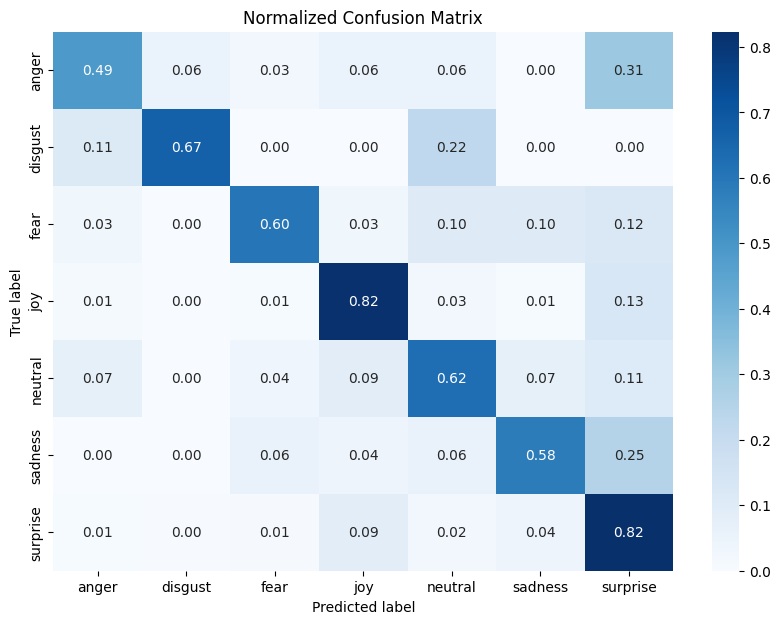

In [17]:
# error analysis
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(true_labels, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_df = pd.DataFrame(cm_normalized, index=emotion_names, columns=emotion_names)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_df, annot=True, fmt='.2f', cmap='Blues')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Normalized Confusion Matrix')
plt.show()

In [20]:
# sentence - predicted - true
misclassified_indices = [i for i, (pred, true) in enumerate(zip(predictions, true_labels)) if pred != true]
misclassified_samples = []
for idx in misclassified_indices:
    text = df_test.iloc[idx]['Translation']
    text_original = df_test.iloc[idx]['Sentence']
    true_emotion = emotion_names[true_labels[idx]]
    predicted_emotion = emotion_names[predictions[idx]]
    misclassified_samples.append((text, text_original, true_emotion, predicted_emotion))
misclassified_df = pd.DataFrame(misclassified_samples, columns=['Text', 'Text Original', 'True Emotion', 'Predicted Emotion'])
misclassified_df.head(20)

,Text,Text Original,True Emotion,Predicted Emotion
0,This is MasterChef.,To jest MasterChef.,disgust,neutral
1,Here they are.,Oto oni.,neutral,surprise
2,which were bustling around the kitchen there.,które tam krzątały się po kuchni.,surprise,joy
3,I was born with a sense for the kitchen and a ...,Urodziłem się z wyczuciem kuchni i z wyczuciem...,joy,surprise
4,I love to eat good things.,Ja uwielbiam jeść dobre rzeczy.,joy,neutral
5,"High stakes, you only win by taking risks.","Wysokie stawki, wygrywa się tylko ryzykiem.",anger,disgust
6,I started under the slogan from cutlet to Mast...,Startowałam pod hasłem od kotleta do Masterchefa.,fear,sadness
7,The Groży prepared an unusual and very demandi...,Groży przygotowali dla nich nietypowe i bardzo...,surprise,joy
8,I enter the market square and look.,Wchodzę na rynek i patrzę.,neutral,sadness
9,We all expected something completely different.,Wszyscy spodziewaliśmy się czegoś zupełnie inn...,neutral,joy


In [21]:
misclassified_df.to_csv("roberta_misclassified_samples.csv", index=False)